<a href="https://colab.research.google.com/github/eliasakalu/ICogLabs_AI_Projects/blob/main/final_vae_assignment_(5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VAE Model: Image Generation & Refill

This notebook implements a **Variational Autoencoder (VAE)** trained on face images to:
1. Reconstruct and generate new face variations from a latent space
2. Refill (inpaint) cut/missing regions of an image using the VAE decoder

## Imports

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
import cv2
from google.colab import files

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Hyperparameters

In [3]:
IMG_SIZE   = 64
LATENT_DIM = 128
BATCH_SIZE = 32
EPOCHS     = 100

## Dataset

LFW (Labeled Faces in the Wild)

In [4]:
def preprocess(data):
    img = tf.cast(data["image"], tf.float32) / 255.0
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.image.random_flip_left_right(img)
    return img

# Using full LFW dataset
ds = tfds.load("lfw", split="train")
ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds = ds.shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Dataset ready. Total batches:", len(ds))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/lfw/incomplete.AHG3MU_0.1.1/lfw-train.tfrecord*...:   0%|          | 0/132…

Dataset lfw downloaded and prepared to /root/tensorflow_datasets/lfw/0.1.1. Subsequent calls will reuse this data.
Dataset ready. Total batches: 414


## Model Architecture

In [5]:
#The layer that accepts hidden encoder output and give mean and logvar
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, log_var = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * eps

In [6]:
# Encoder
enc_input = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(32, 3, strides=2, padding="same")(enc_input)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)

z_mean    = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z         = Sampling()([z_mean, z_log_var])

encoder = keras.Model(enc_input, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  2,097,408 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 128)       │     16,512 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 128)       │     16,512 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 128)       │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,257,472 (8.61 MB)

 Trainable params: 2,257,024 (8.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
# Decoder
start_size = IMG_SIZE // 8

dec_input = keras.Input(shape=(LATENT_DIM,))

x = layers.Dense(128, activation="relu")(dec_input)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(start_size * start_size * 128, activation="relu")(x)
x = layers.Reshape((start_size, start_size, 128))(x)

x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

dec_output = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

decoder = keras.Model(dec_input, dec_output, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8192)           │     2,105,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,396,483 (9.14 MB)

 Trainable params: 2,396,035 (9.14 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.loss_tracker     = keras.metrics.Mean(name="loss")
        self.rec_loss_tracker = keras.metrics.Mean(name="rec_loss")
        self.kl_loss_tracker  = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.loss_tracker, self.rec_loss_tracker, self.kl_loss_tracker]

    def train_step(self, x):
        with tf.GradientTape() as tape:
            mu, log_var, z = self.encoder(x, training=True)
            recon = self.decoder(z, training=True)

            # MSE — mean over all pixels, stays in 0-1 range
            mse = tf.reduce_mean(tf.square(x - recon))

            # SSIM — penalises blurriness directly
            ssim = tf.reduce_mean(1.0 - tf.image.ssim(x, recon, max_val=1.0))

            rec_loss = mse + ssim

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
            )

            total_loss = rec_loss + 0.0005 * kl_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(total_loss)
        self.rec_loss_tracker.update_state(rec_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss":     self.loss_tracker.result(),
            "rec_loss": self.rec_loss_tracker.result(),
            "kl_loss":  self.kl_loss_tracker.result(),
        }

## Training

Epoch 1/100
414/414 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - kl_loss: 10.0079 - loss: 0.8020 - rec_loss: 0.7970
Epoch 2/100
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 13.4476 - loss: 0.7712 - rec_loss: 0.7645
Epoch 3/100
414/414 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - kl_loss: 19.7329 - loss: 0.7519 - rec_loss: 0.7421
Epoch 4/100
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 21.9244 - loss: 0.7355 - rec_loss: 0.7246
Epoch 5/100
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 22.1646 - loss: 0.7274 - rec_loss: 0.7163
Epoch 6/100
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - kl_loss: 23.1848 - loss: 0.7174 - rec_loss: 0.7058
Epoch 7/100
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 23.5345 - loss: 0.7096 - rec_loss: 0.6978
Epoch 8/100
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - kl_loss: 22.8707 - loss: 0.7039 - rec_loss: 0.6925
Epoch 9/100
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 22.1388 - loss: 0.6993 - rec_loss: 0.6883
Epoch 10/100
414/414 ━━━━━━━━━━━━━━

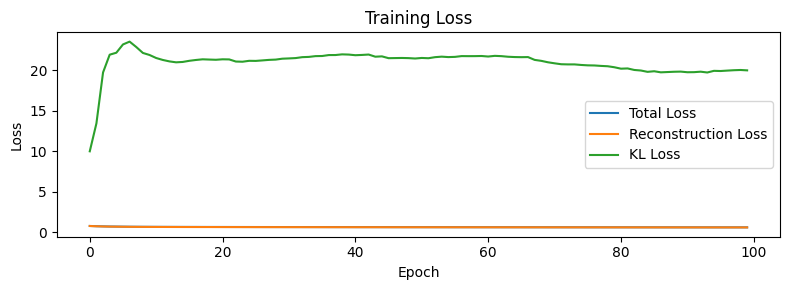

In [9]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

history = vae.fit(ds, epochs=EPOCHS)

plt.figure(figsize=(8, 3))
plt.plot(history.history["loss"],     label="Total Loss")
plt.plot(history.history["rec_loss"], label="Reconstruction Loss")
plt.plot(history.history["kl_loss"],  label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.tight_layout()
plt.show()

---
## Task 1: Image Reconstruction and Variation Generation

A user-uploaded face image is passed through the **encoder** to get its latent representation (mean `μ` and log-variance). The **decoder** reconstructs the image from the sampled latent vector `z`. Five variations are then generated by sampling nearby points in the latent space using the reparameterization trick, showing the generative capability of the VAE.

In [10]:
uploaded = files.upload()
fname    = list(uploaded.keys())[0]

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype("float32") / 255.0

img = load_image(fname)
print("Image shape:", img.shape)

Saving Copilot_20260417_151553.png to Copilot_20260417_151553.png
Image shape: (64, 64, 3)


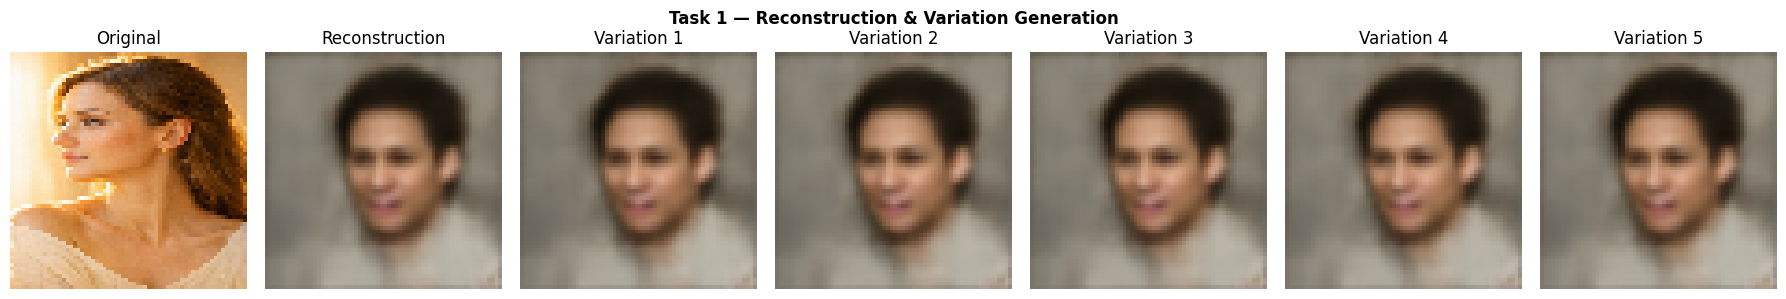

In [14]:
inp = tf.expand_dims(tf.cast(img, tf.float32), 0)
mu, log_var, z = encoder(inp, training=False)
recon = decoder(z, training=False)[0].numpy()

fig, axes = plt.subplots(1, 7, figsize=(18, 3))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(np.clip(recon, 0, 1))
axes[1].set_title("Reconstruction")
axes[1].axis("off")

for i in range(5):
    eps   = tf.random.normal(shape=tf.shape(mu))
    z_new = mu + tf.exp(0.9 * log_var) * eps
    out   = decoder(z_new, training=False)[0].numpy()
    axes[i + 2].imshow(np.clip(out, 0, 1))
    axes[i + 2].set_title(f"Variation {i+1}")
    axes[i + 2].axis("off")

plt.suptitle("Task 1 — Reconstruction & Variation Generation", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Task 2: Image Refill (Inpainting)

A cut/damaged face image (with a black missing region) is uploaded. The missing area is detected automatically by thresholding near-black pixels on the grayscale image, then cleaned up with morphological closing. The VAE generates a complete face from the damaged input, and only the detected missing pixels are replaced from the generated image — all original visible pixels remain untouched.

In [12]:
uploaded2 = files.upload()
fname2    = list(uploaded2.keys())[0]
img_cut   = load_image(fname2)
print("Cut image shape:", img_cut.shape)

Saving blackout.png to blackout.png
Cut image shape: (64, 64, 3)


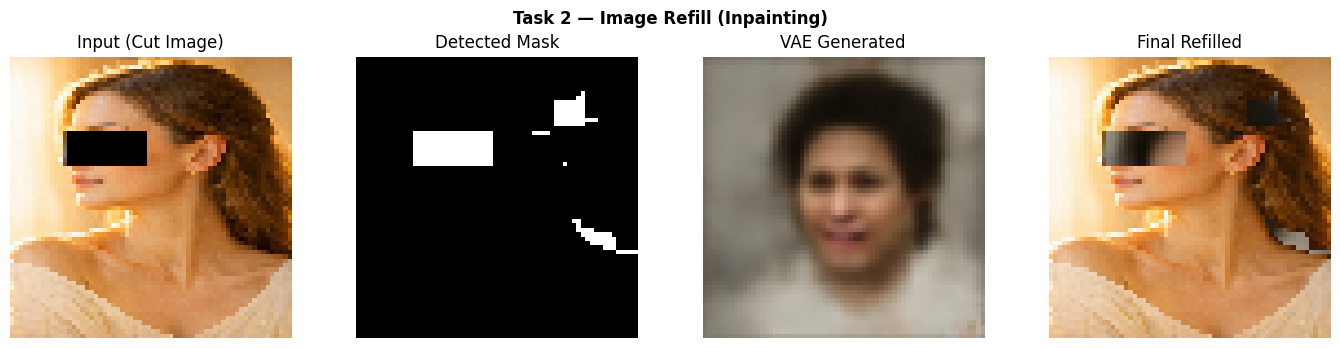

Missing region: 5.7% of pixels


In [13]:
# grayscale
gray = np.mean(img_cut, axis=-1)

# pixels below 8% brightness = missing region
mask = (gray < 0.08).astype("float32")

# morphological closing fills small gaps inside the mask
kernel = np.ones((5, 5), np.uint8)
mask_u8 = (mask * 255).astype(np.uint8)
mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_CLOSE, kernel)
mask = mask_u8.astype("float32") / 255.0

# expand to 3 channels
mask3 = np.stack([mask] * 3, axis=-1)

# Generate a full face from the VAE
inp2 = tf.expand_dims(tf.cast(img_cut, tf.float32), 0)
mu2, lv2, z2 = encoder(inp2, training=False)
generated = decoder(z2, training=False)[0].numpy()

# Paste only the missing region from generated onto the original
result = img_cut * (1.0 - mask3) + generated * mask3
result = np.clip(result, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

axes[0].imshow(img_cut)
axes[0].set_title("Input (Cut Image)")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Detected Mask")
axes[1].axis("off")

axes[2].imshow(np.clip(generated, 0, 1))
axes[2].set_title("VAE Generated")
axes[2].axis("off")

axes[3].imshow(result)
axes[3].set_title("Final Refilled")
axes[3].axis("off")

plt.suptitle("Task 2 — Image Refill (Inpainting)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Missing region: {mask.mean() * 100:.1f}% of pixels")